# Step 2 — Graph Autoencoder on Karate Club

This notebook implements a **Graph Autoencoder (GAE)** on the Karate Club graph.
We train the model to reconstruct the adjacency matrix from learned node embeddings,
then compare the results against the Laplacian eigenmap baseline from notebook `01`.

**Contents:**
1. Define GAE architecture (GCN encoder + inner-product decoder)
2. Train on adjacency reconstruction (full graph)
3. Visualize learned embeddings and compare to spectral baseline
4. Community recovery (KMeans on embeddings)
5. Link prediction with held-out edges
6. Latent dimension sensitivity analysis

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_dense_adj, to_networkx, negative_sampling
from torch_geometric.nn import GCNConv
from sklearn.cluster import KMeans
from sklearn.metrics import (
    normalized_mutual_info_score, accuracy_score, roc_auc_score, average_precision_score
)

torch.manual_seed(42)
np.random.seed(42)

# Load data
dataset = KarateClub()
data = dataset[0]
A = to_dense_adj(data.edge_index).squeeze(0)
labels = data.y.numpy()
n = data.num_nodes

print(f"Nodes: {n}, Edges: {data.num_edges // 2}")

Nodes: 34, Edges: 78


## 1. GAE Architecture

**Encoder:** Two-layer GCN that maps node features $X$ and edge structure to a
latent embedding $Z \in \mathbb{R}^{n \times d}$.

**Decoder:** Inner product — $\hat{A}_{ij} = \sigma(z_i^\top z_j)$

In [2]:
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x


class GraphAutoencoder(torch.nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def decode(self, z):
        """Inner-product decoder → reconstructed adjacency."""
        return torch.sigmoid(z @ z.t())

    def decode_edges(self, z, edge_index):
        """Decode specific edges (for link prediction)."""
        src, dst = edge_index
        return torch.sigmoid((z[src] * z[dst]).sum(dim=1))

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        return self.decode(z), z

## 2. Training — Full Adjacency Reconstruction

Train the GAE to minimize binary cross-entropy between $A$ and $\hat{A}$.

Training GAE (latent_dim=2):
  Epoch  50 | Loss: 0.6522
  Epoch 100 | Loss: 0.6393
  Epoch 150 | Loss: 0.6247
  Epoch 200 | Loss: 0.6228
  Epoch 250 | Loss: 0.6224
  Epoch 300 | Loss: 0.6222


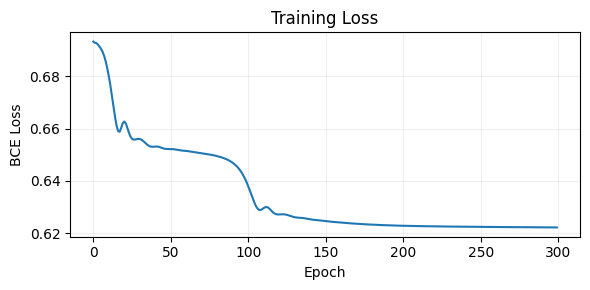

In [3]:
def train_gae(data, latent_dim=2, hidden_dim=16, lr=0.01, epochs=300, verbose=True):
    """Train a GAE and return the model, loss history, and final embeddings."""
    encoder = GCNEncoder(data.num_node_features, hidden_dim, latent_dim)
    model = GraphAutoencoder(encoder)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    A_target = to_dense_adj(data.edge_index).squeeze(0)

    losses = []
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        A_hat, z = model(data.x.float(), data.edge_index)
        loss = F.binary_cross_entropy(A_hat, A_target)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if verbose and epoch % 50 == 0:
            print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        A_hat, z = model(data.x.float(), data.edge_index)

    return model, losses, z.numpy(), A_hat.numpy()


print("Training GAE (latent_dim=2):")
model, losses, Z_gae, A_hat = train_gae(data, latent_dim=2, epochs=300)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Training Loss")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Reconstruction Quality

Full reconstruction AUC: 0.9103
Full reconstruction AP:  0.7582


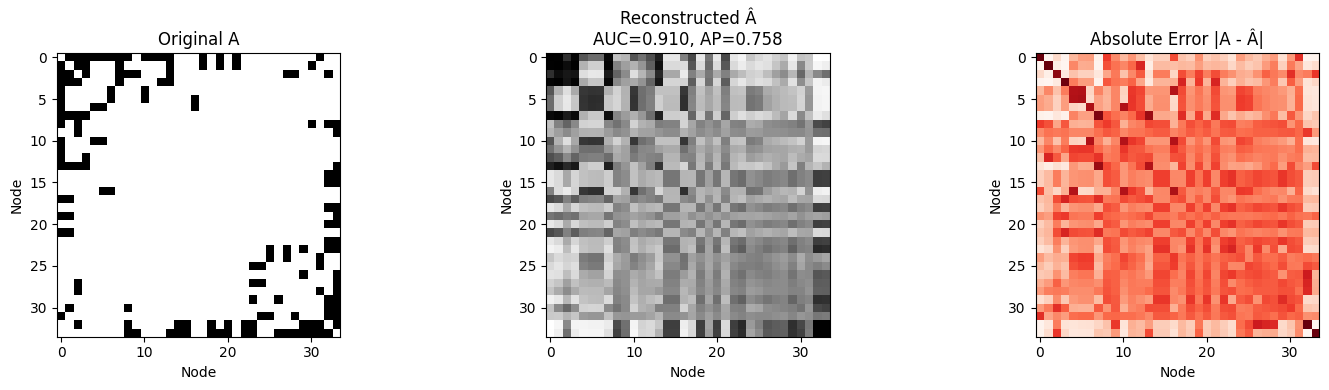

In [4]:
A_np = A.numpy()

# AUC on all node pairs (excluding self-loops)
mask = ~np.eye(n, dtype=bool)
auc = roc_auc_score(A_np[mask].flatten(), A_hat[mask].flatten())
ap = average_precision_score(A_np[mask].flatten(), A_hat[mask].flatten())

print(f"Full reconstruction AUC: {auc:.4f}")
print(f"Full reconstruction AP:  {ap:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(A_np, cmap="Greys", interpolation="none")
axes[0].set_title("Original A")

axes[1].imshow(A_hat, cmap="Greys", interpolation="none")
axes[1].set_title(f"Reconstructed Â\nAUC={auc:.3f}, AP={ap:.3f}")

axes[2].imshow(np.abs(A_np - A_hat), cmap="Reds", interpolation="none")
axes[2].set_title("Absolute Error |A - Â|")

for ax in axes:
    ax.set_xlabel("Node")
    ax.set_ylabel("Node")

plt.tight_layout()
plt.show()

## 4. Embedding Visualization & Comparison to Spectral Baseline

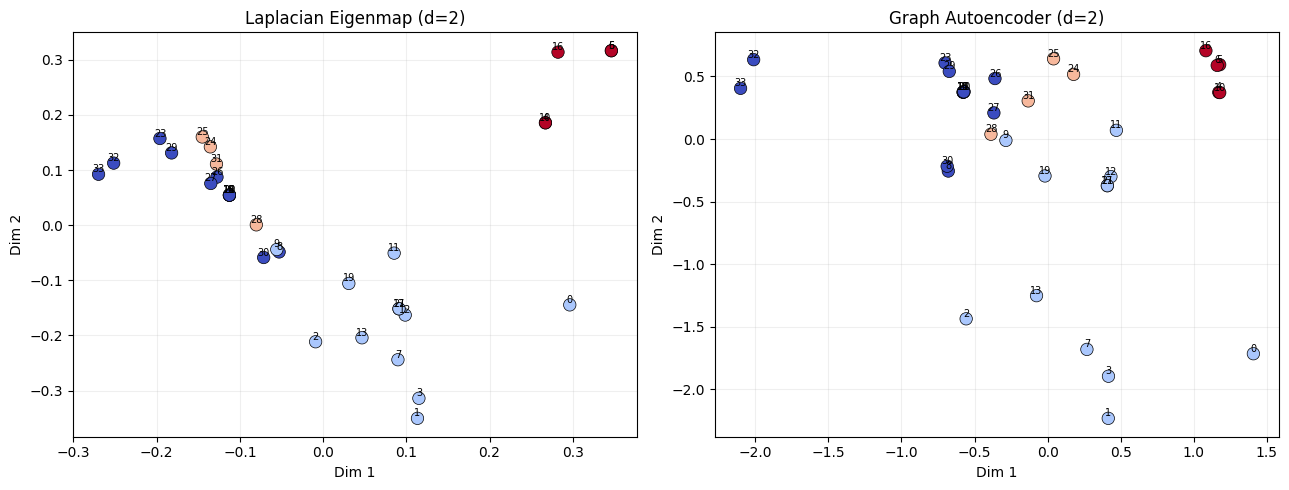

In [5]:
# Recompute Laplacian eigenmap for comparison
def laplacian_eigenmap(A, n_components=2):
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    L = D - A
    inv_sqrt = np.where(degrees > 0, 1.0 / np.sqrt(degrees), 0.0)
    L_norm = np.diag(inv_sqrt) @ L @ np.diag(inv_sqrt)
    eigvals, eigvecs = np.linalg.eigh(L_norm)
    idx = np.argsort(eigvals)
    nontrivial = idx[eigvals[idx] > 1e-10][:n_components]
    return eigvecs[:, nontrivial]

Z_le = laplacian_eigenmap(A_np, n_components=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, Z, title in [
    (axes[0], Z_le, "Laplacian Eigenmap (d=2)"),
    (axes[1], Z_gae, "Graph Autoencoder (d=2)"),
]:
    ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="coolwarm", s=80,
              edgecolor="k", linewidth=0.5, zorder=3)
    for i in range(n):
        ax.annotate(str(i), (Z[i, 0], Z[i, 1]), fontsize=7, ha="center", va="bottom")
    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Community Recovery

In [6]:
def clustering_metrics(Z, labels, n_clusters=2):
    km = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    pred = km.fit_predict(Z)
    nmi = normalized_mutual_info_score(labels, pred)
    acc = max(accuracy_score(labels, pred), accuracy_score(labels, 1 - pred))
    return pred, nmi, acc

_, nmi_le, acc_le = clustering_metrics(Z_le, labels)
_, nmi_gae, acc_gae = clustering_metrics(Z_gae, labels)

print(f"{'Method':<25} {'NMI':>8} {'Accuracy':>10}")
print("-" * 45)
print(f"{'Laplacian Eigenmap':<25} {nmi_le:>8.4f} {acc_le*100:>9.1f}%")
print(f"{'Graph Autoencoder':<25} {nmi_gae:>8.4f} {acc_gae*100:>9.1f}%")

Method                         NMI   Accuracy
---------------------------------------------
Laplacian Eigenmap          0.4952      38.2%
Graph Autoencoder           0.2552      55.9%


## 6. Link Prediction with Held-Out Edges

Randomly mask ~15% of edges, train on the remaining, and evaluate the decoder's
ability to predict the held-out edges.

In [7]:
from torch_geometric.transforms import RandomLinkSplit

# Split edges: 85% train, 5% val, 10% test
transform = RandomLinkSplit(
    num_val=0.05,
    num_test=0.10,
    is_undirected=True,
    add_negative_train_samples=False,
)
train_data, val_data, test_data = transform(data)

print(f"Train edges: {train_data.edge_index.shape[1] // 2}")
print(f"Val edges:   {val_data.edge_label_index.shape[1] // 2} pos + neg")
print(f"Test edges:  {test_data.edge_label_index.shape[1] // 2} pos + neg")

Train edges: 68
Val edges:   3 pos + neg
Test edges:  7 pos + neg


In [8]:
# Train on reduced edge set
encoder_lp = GCNEncoder(data.num_node_features, 16, 8)
model_lp = GraphAutoencoder(encoder_lp)
optimizer = torch.optim.Adam(model_lp.parameters(), lr=0.01)

A_train = to_dense_adj(train_data.edge_index).squeeze(0)

model_lp.train()
for epoch in range(1, 301):
    optimizer.zero_grad()
    A_hat_train, z = model_lp(data.x.float(), train_data.edge_index)
    loss = F.binary_cross_entropy(A_hat_train, A_train)
    loss.backward()
    optimizer.step()

print(f"Final training loss: {loss.item():.4f}")

# Evaluate on test edges
model_lp.eval()
with torch.no_grad():
    z = model_lp.encode(data.x.float(), train_data.edge_index)
    test_pred = model_lp.decode_edges(z, test_data.edge_label_index)

test_labels = test_data.edge_label.numpy()
test_scores = test_pred.numpy()

test_auc = roc_auc_score(test_labels, test_scores)
test_ap = average_precision_score(test_labels, test_scores)

print(f"\nLink Prediction Results (held-out test set):")
print(f"  AUC: {test_auc:.4f}")
print(f"  AP:  {test_ap:.4f}")

Final training loss: 0.6186

Link Prediction Results (held-out test set):
  AUC: 0.7551
  AP:  0.8361


## 7. Latent Dimension Sensitivity

Train GAEs with different latent dimensions and compare reconstruction + community recovery.


Training GAE with latent_dim=2:
  AUC=0.9101, NMI=0.2552, Acc=55.9%, Loss=0.6221

Training GAE with latent_dim=4:
  AUC=0.9340, NMI=0.2552, Acc=55.9%, Loss=0.6068

Training GAE with latent_dim=8:
  AUC=0.9389, NMI=0.2552, Acc=55.9%, Loss=0.6057

Training GAE with latent_dim=16:
  AUC=0.9507, NMI=0.2552, Acc=55.9%, Loss=0.5988


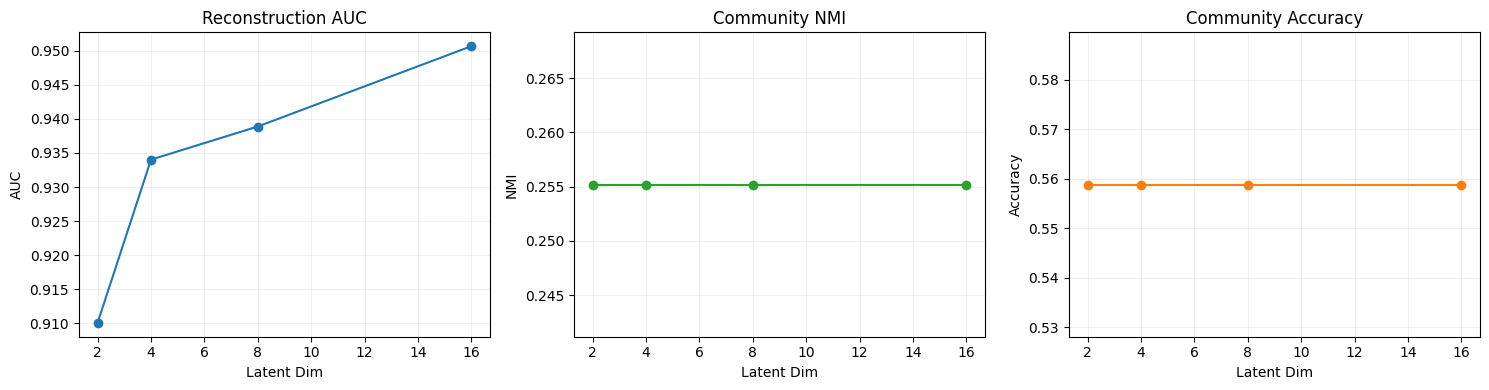

In [9]:
dims = [2, 4, 8, 16]
results = []

for d in dims:
    print(f"\nTraining GAE with latent_dim={d}:")
    _, losses_d, Z_d, A_hat_d = train_gae(data, latent_dim=d, epochs=300, verbose=False)

    # Reconstruction
    mask = ~np.eye(n, dtype=bool)
    auc_d = roc_auc_score(A_np[mask].flatten(), A_hat_d[mask].flatten())

    # Community
    _, nmi_d, acc_d = clustering_metrics(Z_d, labels)

    results.append({"dim": d, "auc": auc_d, "nmi": nmi_d, "acc": acc_d, "final_loss": losses_d[-1]})
    print(f"  AUC={auc_d:.4f}, NMI={nmi_d:.4f}, Acc={acc_d*100:.1f}%, Loss={losses_d[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot([r["dim"] for r in results], [r["auc"] for r in results], "o-")
axes[0].set_title("Reconstruction AUC")
axes[0].set_xlabel("Latent Dim")
axes[0].set_ylabel("AUC")
axes[0].grid(alpha=0.2)

axes[1].plot([r["dim"] for r in results], [r["nmi"] for r in results], "o-", color="tab:green")
axes[1].set_title("Community NMI")
axes[1].set_xlabel("Latent Dim")
axes[1].set_ylabel("NMI")
axes[1].grid(alpha=0.2)

axes[2].plot([r["dim"] for r in results], [r["acc"] for r in results], "o-", color="tab:orange")
axes[2].set_title("Community Accuracy")
axes[2].set_xlabel("Latent Dim")
axes[2].set_ylabel("Accuracy")
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Summary

**Key findings (to be filled after running):**

| Metric | Laplacian Eigenmap | GAE (d=2) | GAE (d=16) |
|--------|-------------------|-----------|------------|
| Community NMI | — | — | — |
| Community Acc | — | — | — |
| Recon AUC | N/A | — | — |
| Link Pred AUC | N/A | — | — |

